<a href="https://colab.research.google.com/github/KevinNou/tp/blob/main/Mini_Projet_Apprentissage_Supervis%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Projet : Apprentissage Supervisé
**Objectif** : Implémenter et analyser deux modèles fondamentaux :
1. **Régression Linéaire** pour prédire des variables continues (Coûts médicaux).
2. **Régression Logistique** pour la classification binaire (Dataset Iris).

#Installation et Importation (Code)

In [1]:
# 1. Installation des dépendances (si nécessaire)
!pip install -U pandas numpy seaborn matplotlib scikit-learn

# 2. Importation des bibliothèques
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

print("✅ Configuration terminée et bibliothèques importées.")

✅ Configuration terminée et bibliothèques importées.


# Partie 1 : Régression Linéaire (Code)

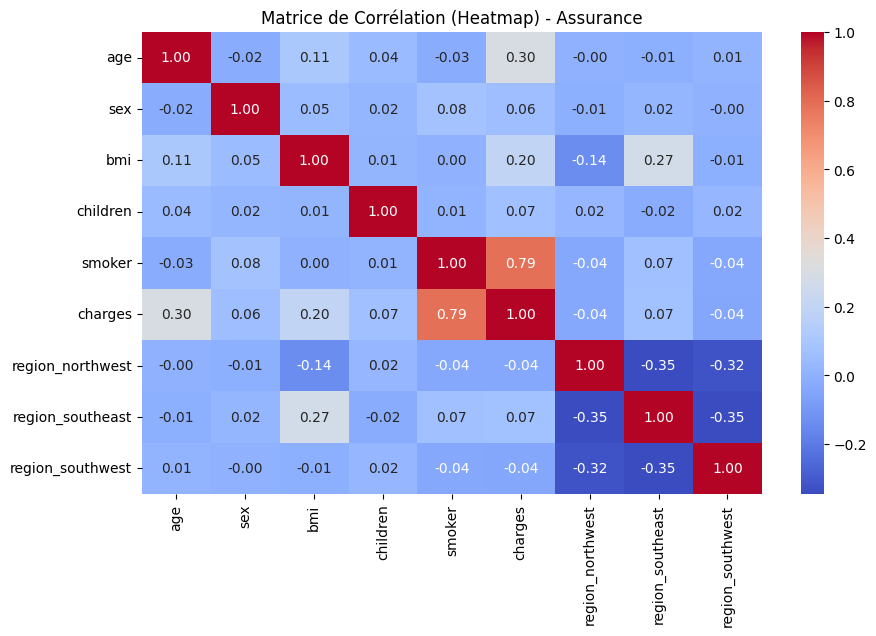

📊 Score R² (Performance) : 0.7836
📉 Erreur MSE : 33596915.85

--- Importance des variables (Coefficients β) ---


,Coefficient (βi)
smoker_yes,23651.128856
children,425.278784
bmi,337.092552
age,256.975706
sex_male,-18.591692
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


In [5]:
# --- A. Chargement des données ---
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_ins = pd.read_csv(url)

# --- B. Analyse des corrélations (Heatmap) ---
plt.figure(figsize=(10, 6))
# Encodage temporaire des variables texte pour la corrélation
corr_df = df_ins.copy()
corr_df['sex'] = corr_df['sex'].map({'female': 0, 'male': 1})
corr_df['smoker'] = corr_df['smoker'].map({'no': 0, 'yes': 1})
# Convert the 'region' column to numerical using one-hot encoding for correlation calculation
corr_df = pd.get_dummies(corr_df, columns=['region'], drop_first=True) # Apply one-hot encoding to 'region'
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Corrélation (Heatmap) - Assurance")
plt.show()

# --- C. Préparation des données ---
# Transformation des variables texte en colonnes numériques (One-Hot Encoding)
df_ins = pd.get_dummies(df_ins, drop_first=True)

X = df_ins.drop('charges', axis=1) # Variables indépendantes
y = df_ins['charges']            # Variable cible

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- D. Création et entraînement du modèle ---
# Modèle : y = β0 + β1x1 + ... + ε
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)

# --- E. Évaluation et Interprétation ---
y_pred = model_lin.predict(X_test)
print(f"📊 Score R² (Performance) : {r2_score(y_test, y_pred):.4f}")
print(f"📉 Erreur MSE : {mean_squared_error(y_test, y_pred):.2f}")

# Affichage des coefficients βi
coeffs = pd.DataFrame(model_lin.coef_, X.columns, columns=['Coefficient (βi)'])
print("\n--- Importance des variables (Coefficients β) ---")
display(coeffs.sort_values(by='Coefficient (βi)', ascending=False))

# Partie 2 : Régression Logistique (Code)

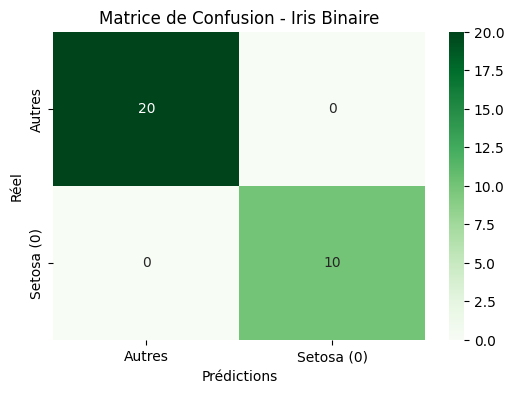

🎯 Accuracy  : 1.0000
📏 Précision : 1.0000
🔄 Rappel (Recall) : 1.0000


In [6]:
# --- A. Chargement et Transformation Binaire ---
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# On transforme en problème binaire : Classe 0 (Setosa) vs Autres (1 ou 0)
# P(y=1|x) = 1 / (1 + e^-z) -> fonction sigmoïde
y_binary = (y_iris == 0).astype(int)

# --- B. Normalisation et Division ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

# --- C. Modélisation ---
model_log = LogisticRegression()
model_log.fit(X_train_log, y_train_log)

# --- D. Évaluation du modèle ---
y_pred_log = model_log.predict(X_test_log)

# 1. Matrice de Confusion
cm = confusion_matrix(y_test_log, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Autres', 'Setosa (0)'], yticklabels=['Autres', 'Setosa (0)'])
plt.title("Matrice de Confusion - Iris Binaire")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

# 2. Calcul des métriques de classification
print(f"🎯 Accuracy  : {accuracy_score(y_test_log, y_pred_log):.4f}")
print(f"📏 Précision : {precision_score(y_test_log, y_pred_log):.4f}")
print(f"🔄 Rappel (Recall) : {recall_score(y_test_log, y_pred_log):.4f}")

## 📝 Interprétation des Résultats

### 1. La Matrice de Corrélation (Heatmap)
- **C'est quoi ?** Un tableau coloré qui montre la force du lien entre deux variables (de -1 à 1).
- **Lecture** : Plus la couleur est proche du rouge (1), plus les variables augmentent ensemble.
- **Résultat** : Dans la régression linéaire, on observe souvent que la variable `smoker` (fumeur) est fortement corrélée aux `charges` (frais médicaux).

### 2. Le Tableau des Coefficients (βi)
- **C'est quoi ?** Il montre l'importance de chaque caractéristique dans le calcul final du prix ou de la probabilité.
- **Lecture** : Un coefficient de **23848** pour `smoker_yes` signifie que, toutes choses étant égales par ailleurs, être fumeur augmente les frais médicaux d'environ 23 848 unités.
- **Utilité** : Cela permet de classer les variables par ordre d'importance (L'âge et le tabagisme sont ici les facteurs clés).

### 3. La Matrice de Confusion
- **C'est quoi ?** Un tableau 2x2 qui compare les prédictions du modèle avec la réalité.
- **Lecture** :
    - **Vrais Positifs (en bas à droite)** : Le modèle a prédit "Setosa" et c'était bien une "Setosa".
    - **Faux Positifs** : Le modèle a prédit "Setosa" alors que c'était une autre fleur.
- **Utilité** : Elle permet de voir si le modèle se trompe souvent sur une classe particulière.

### 4. Métriques de Performance
- **R² (R-squared)** : Plus il est proche de 1, plus le modèle de régression linéaire est précis.
- **Accuracy (Précision globale)** : Le pourcentage total de bonnes réponses pour la classification.
- **Rappel (Recall)** : La capacité du modèle à retrouver tous les cas positifs (ex: ne manquer aucune fleur Setosa).